# 04 — Análise e visualizações (1% do corpus)

Executa o pipeline analítico da Fase 5 sobre o sample de 1% (176 docs) e
renderiza o conjunto de gráficos de `src.analise.viz`.

**Modo de operação:**
- Se `data/processed/classificacoes.parquet` existir (LLM real), usa.
- Caso contrário, **gera classificações sintéticas plausíveis** via
  `src.classificacao.synth` — serve para desenvolver viz antes de
  rodar o LLM.
- Se `data/processed/validacoes_humanas.parquet` existir, também aplica
  concordância + calibração; senão, pula essas células.

Outputs: PNG em `data/processed/analise/figures/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path('..').resolve()))

BASE = Path('..')
AMOSTRA = BASE / 'data/interim/metadados_amostra1pct.parquet'
META_FULL = BASE / 'data/interim/metadados.parquet'
CLS_PATH = BASE / 'data/processed/classificacoes.parquet'
VAL_PATH = BASE / 'data/processed/validacoes_humanas.parquet'
FIG_DIR = BASE / 'data/processed/analise/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

amostra = pd.read_parquet(AMOSTRA)
print(f'Sample 1%: {len(amostra)} docs')
print(amostra.groupby((amostra.ano // 10 * 10).astype('Int64')).size().to_string())

Sample 1%: 176 docs
ano
1960     2
1970     8
1980    13
1990    19
2000    28
2010    61
2020    45


In [2]:
from src.classificacao.synth import synth_classificacoes

if CLS_PATH.exists():
    cls = pd.read_parquet(CLS_PATH)
    cls = cls[cls['document_id'].isin(amostra['id'])]
    print(f'Usando classificações REAIS: {len(cls)} linhas')
else:
    cls = synth_classificacoes(amostra, random_state=42)
    print(f'Usando classificações SINTÉTICAS: {len(cls)} linhas (5 dims × {len(amostra)} docs)')
print(cls.head(3))

Usando classificações SINTÉTICAS: 880 linhas (5 dims × 176 docs)
                            document_id dimensao  score trechos_evidencia  \
0  ce6e87b3-5403-4763-a07b-f26dd095ef30       D1      4         [[synth]]   
1  13e381d5-fc39-49a7-9194-bb45daa9e609       D1      2         [[synth]]   
2  18b9f1b5-bffd-4628-8c7c-aa6572f00d62       D1      2         [[synth]]   

                                    justificativa     modelo prompt_version  \
0  [sintético] baseline=2.60 + deriva + tipo_eff.  synth-1.0      synth-1.0   
1  [sintético] baseline=2.60 + deriva + tipo_eff.  synth-1.0      synth-1.0   
2  [sintético] baseline=2.60 + deriva + tipo_eff.  synth-1.0      synth-1.0   

   tokens_input  tokens_output                         timestamp  
0             0              0  2026-04-22T15:13:20.245118+00:00  
1             0              0  2026-04-22T15:13:20.245118+00:00  
2             0              0  2026-04-22T15:13:20.245118+00:00  


In [3]:
from src.analise import media_por_decada, media_por_decada_e_tipo, top_palavras_por_polo

# prepare: se houver score_calibrado usamos, senão score
if 'score_calibrado' not in cls.columns:
    cls['score_calibrado'] = cls['score'].astype(float)

media = media_por_decada(cls, amostra)
print('=== Média por década × dimensão ===')
print(media.round(2))

=== Média por década × dimensão ===
dimensao    D1    D2    D3    D4    D5
decada                                
1960      3.00  3.00  3.00  2.50  3.50
1970      2.75  2.50  2.25  2.50  2.38
1980      2.62  2.77  2.31  2.15  2.92
1990      2.42  2.47  2.42  2.42  3.16
2000      2.54  2.68  2.39  2.75  2.96
2010      2.66  2.75  2.36  2.41  3.02
2020      2.82  2.71  2.27  2.49  2.98


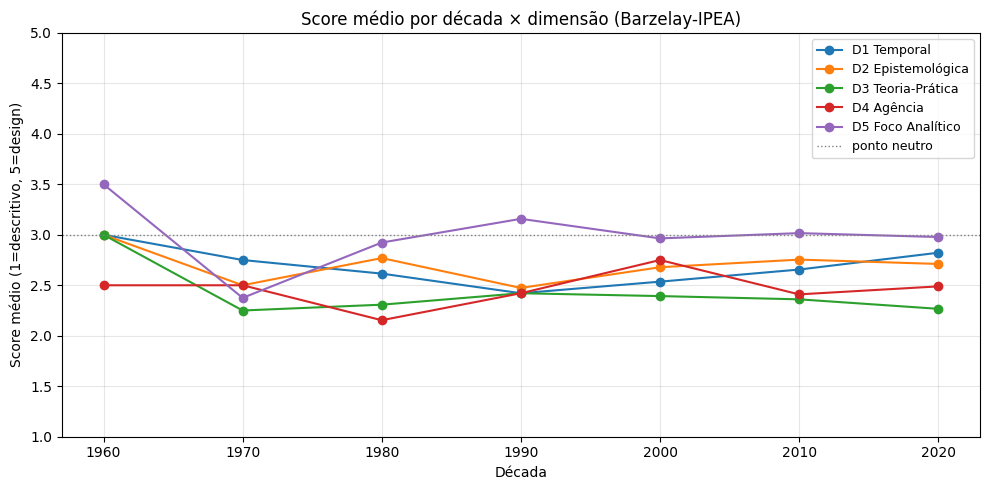

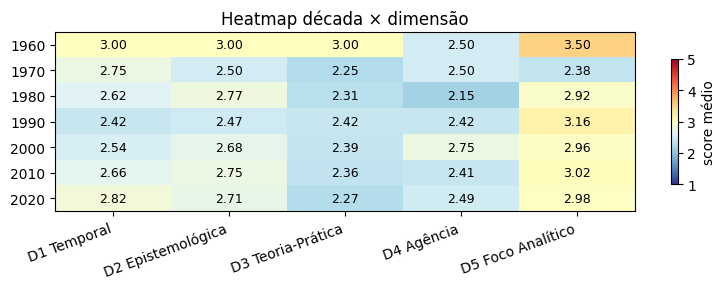

In [4]:
from src.analise.viz import plot_media_por_decada, plot_heatmap_decada_dimensao

plot_media_por_decada(media, save_to=FIG_DIR / '01_media_por_decada.png');
plot_heatmap_decada_dimensao(media, save_to=FIG_DIR / '02_heatmap_decada_dim.png');

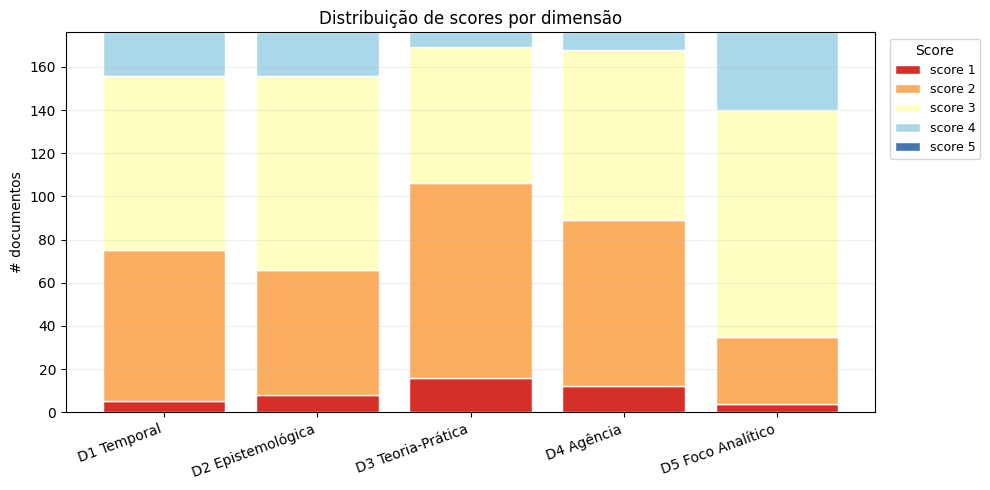

In [5]:
from src.analise.viz import plot_distribuicao_scores
plot_distribuicao_scores(cls, save_to=FIG_DIR / '03_distribuicao_scores.png');

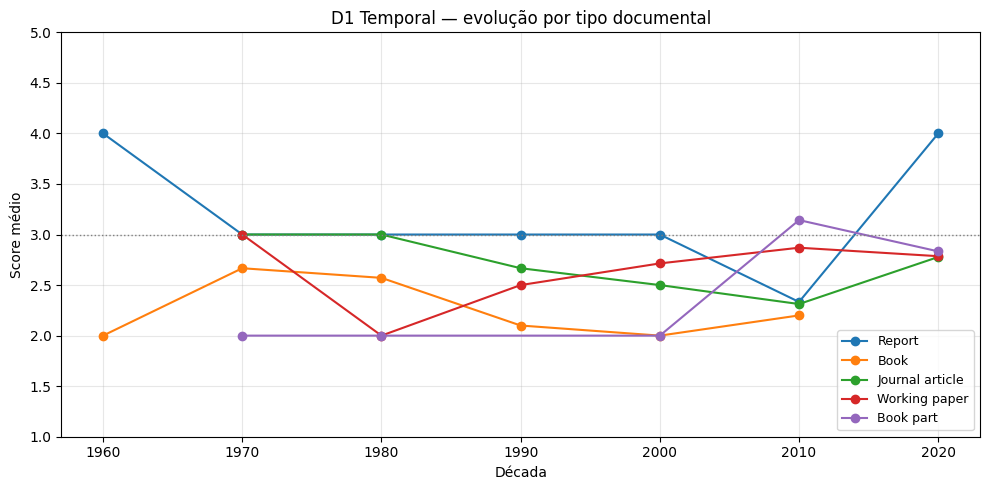

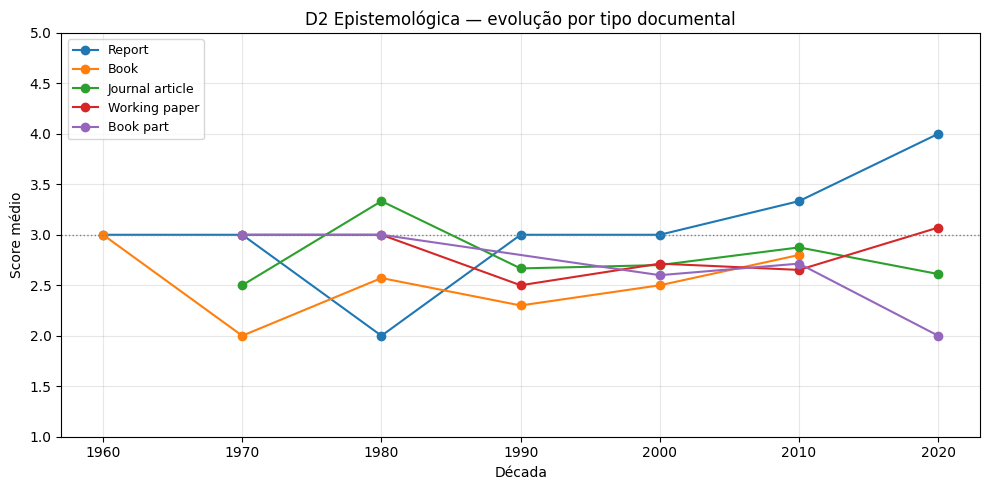

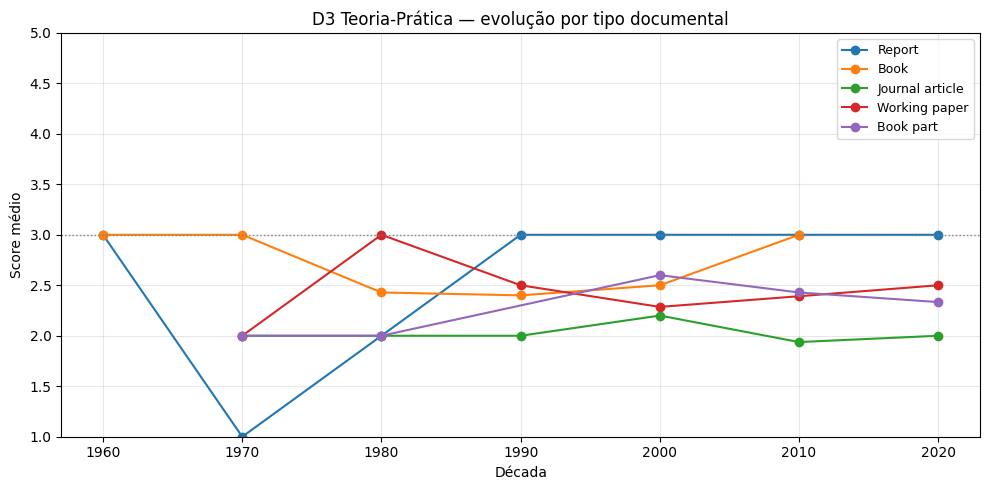

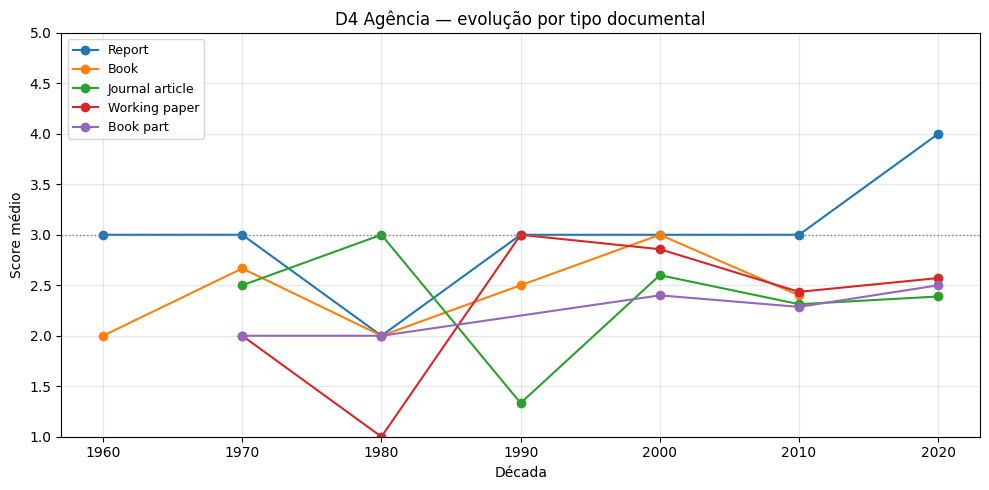

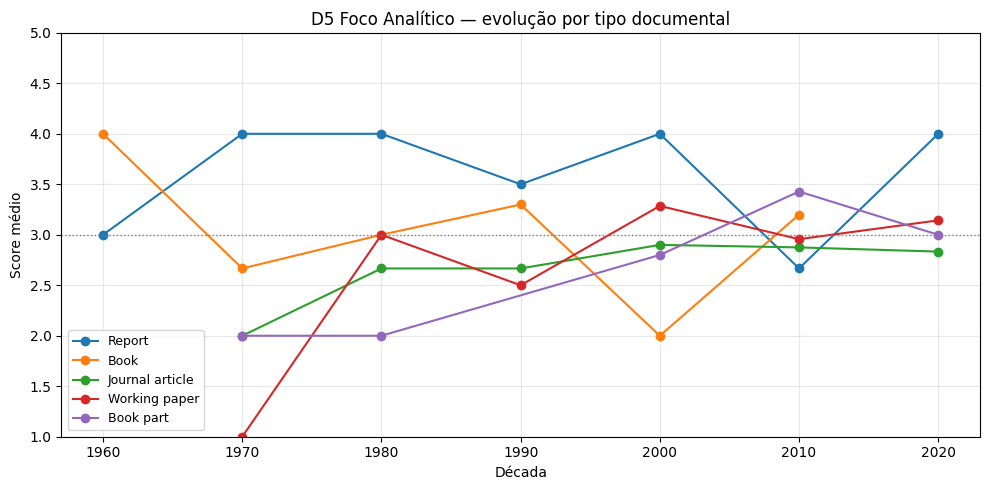

In [6]:
from src.analise.viz import plot_media_por_tipo
long_dt = media_por_decada_e_tipo(cls, amostra)
for dim in ['D1', 'D2', 'D3', 'D4', 'D5']:
    plot_media_por_tipo(long_dt, dimensao=dim, save_to=FIG_DIR / f'04_tipo_{dim}.png');

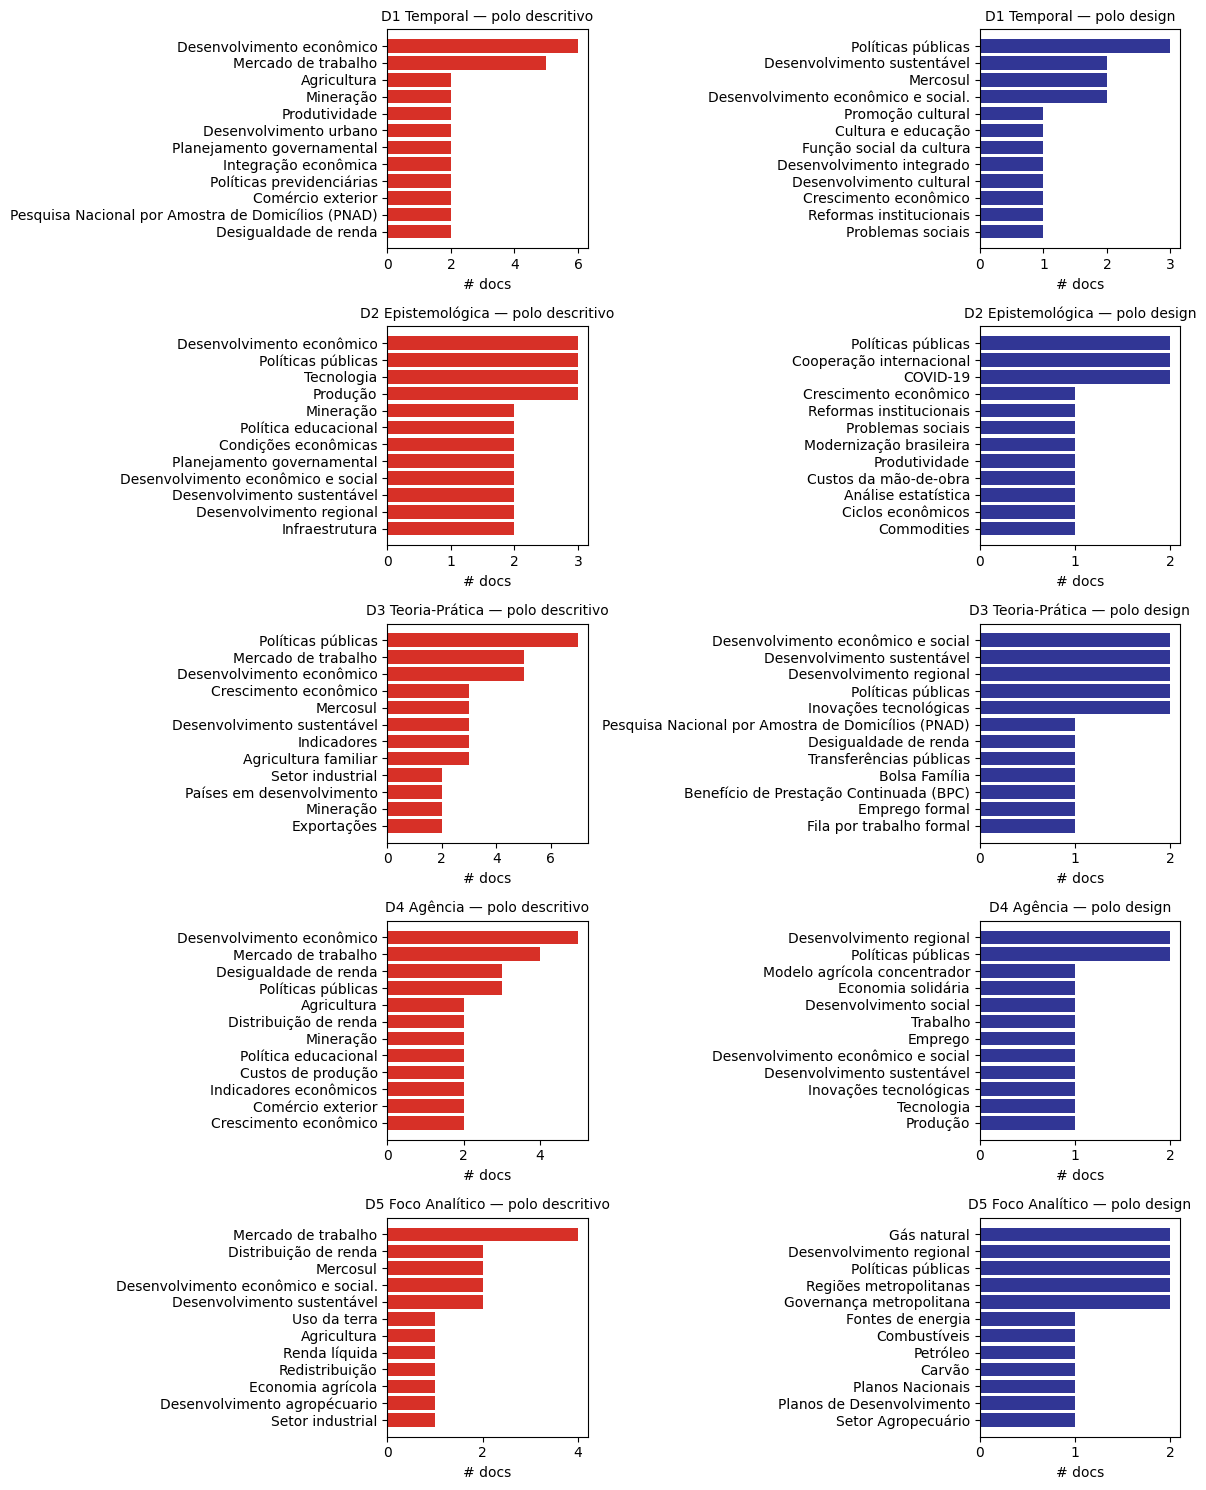

In [7]:
from src.analise.viz import plot_top_palavras_polo
tops = {d: top_palavras_por_polo(cls, amostra, dimensao=d) for d in ['D1', 'D2', 'D3', 'D4', 'D5']}
plot_top_palavras_polo(tops, top_n=12, save_to=FIG_DIR / '05_palavras_polo.png');

In [8]:
from src.analise import cohen_kappa_llm_vs_humano, treinar_calibradores, aplicar_calibradores
from src.analise.viz import plot_cohen_kappa, plot_scatter_llm_vs_humano, plot_curvas_calibracao

if VAL_PATH.exists():
    val = pd.read_parquet(VAL_PATH)
    kappas = cohen_kappa_llm_vs_humano(cls, val)
    plot_cohen_kappa(kappas, save_to=FIG_DIR / '06_cohen_kappa.png')
    plot_scatter_llm_vs_humano(cls, val, save_to=FIG_DIR / '07_scatter_llm_humano.png')
    cals = treinar_calibradores(cls, val)
    if cals:
        plot_curvas_calibracao(cals, save_to=FIG_DIR / '08_calibracao.png')
        cls = aplicar_calibradores(cls, cals)
    print('Concordância + calibração renderizadas.')
else:
    print('Sem validações humanas — gráficos 06-08 pulados.')
    print('Rode a Fase 4 (Streamlit) para gerar validacoes_humanas.parquet.')

Sem validações humanas — gráficos 06-08 pulados.
Rode a Fase 4 (Streamlit) para gerar validacoes_humanas.parquet.


In [9]:
print('\nFiguras geradas em', FIG_DIR.resolve())
for p in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p.name}  {p.stat().st_size // 1024}KB')


Figuras geradas em /home/user/IDEA/barzelay-ipea/data/processed/analise/figures
  01_media_por_decada.png  106KB
  02_heatmap_decada_dim.png  82KB
  03_distribuicao_scores.png  68KB
  04_tipo_D1.png  97KB
  04_tipo_D2.png  101KB
  04_tipo_D3.png  93KB
  04_tipo_D4.png  110KB
  04_tipo_D5.png  116KB
  05_palavras_polo.png  505KB
